In [1]:
import numpy as np
import pandas as pd
from torch.utils.data import TensorDataset, DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
#!pip install lingpy
#import lingpy
#from lingpy import ipa2tokens
import re

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#device = torch.device("cpu") #For debugging
print(f"Using device: {device}")
torch.set_default_device(device)

Using device: cuda


In [2]:
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

## IELEX

In [3]:
import pandas as pd
from itertools import combinations

df = pd.read_csv("data/ielexData.csv")

df = df[['Meaning', 'Phonological Form', 'cc']].dropna()
df.columns = ['meaning', 'word', 'cognate_class']

ielexGroups = []

for _, group in df.groupby('meaning'):
    entries = group.to_dict('records')

    # entries is a dict, like {'meaning': 'water', 'word': 'woda', 'cognate_class': 1}
    ielexGroups.append(entries)

import csv

# Initialize an empty set to store the languages
languages = set()

# Open and read the CSV file with UTF-8 encoding and error handling
with open('data/ielexData.csv', 'r', encoding='utf-8', errors='replace') as file:
    reader = csv.reader(file)
    next(reader)  # Skip the header row
    for row in reader:
        languages.add(row[1])  # Add the language (second column) to the set

# Print the set of languages
print(languages)

df

{'French', 'Icelandic', 'Russian', 'English', 'Bulgarian', 'Czech', 'Italian', 'German', 'Hindi', 'Spanish', 'Greek', 'Breton', 'Ukrainian', 'Welsh', 'Romanian', 'Irish', 'Portuguese', 'Bengali', 'Nepali', 'Polish', 'Dutch', 'Swedish', 'Danish', 'Catalan', 'Lithuanian'}


,meaning,word,cognate_class
0,few,ˈliʝi,few:I
1,few,ˈmaɫku,few:H
2,few,'maɫɔ,few:H
3,few,ˈmawɔ,few:H
4,few,ˈmaɫɔ,few:H
...,...,...,...
4479,head,tɛt,head:D
4480,head,'tɛsta,head:D
4481,head,kap,head:B
4482,head,ˈpɛnː,head:E


## GLED

### Preprocessing

In [4]:
df = pd.read_csv("data/gled.tsv", delimiter="\t")

df.rename(columns={'LANGUAGE_NAME': 'Language'}, inplace=True)

df['Language'] = df['Language'].str.replace('Modern Greek', 'Greek', regex=False)

# more_languages = {"English", "Spanish", "Hindi", "Portuguese", "Bengali", "Russian", "Japanese", "Punjabi", "German", "Vietnamese", "Javanese", "Malay/Indonesian", "Telugu", "Korean", "French", "Marathi", "Tamil", "Turkish", "Urdu", "Gujarati", "Polish", "Ukrainian", "Italian", "Malayalam", "Kannada", "Oriya", "Sundanese", "Romanian", "Hausa", "Burmese", "Thai", "Dutch", "Yoruba", "Sindhi", "Amharic", "Tagalog", "Nepali", "Cebuano", "Assamese", "Hungarian", "Sinhala", "Czech", "Greek", "Belarusan", "Somali", "Malagasy", "Zulu", "Bulgarian", "Swedish"}
# languages.update(more_languages)

df = df[df['Language'].isin(languages)]

#df = df[df.apply(lambda row: row['DOCULECT'].lower() in row['Language'].lower(), axis=1)]

#These languages seem to be aight
#df = df[df["DOCULECT"].str.contains("_2")]

#df.dropna(subset=["COGSET"], inplace=True) All of them have a cogset

df

,ID,DOCULECT,Language,GLOTTOCODE,GLOTTOLOG_NAME,FAMILY,CONCEPT,CONCEPTICON_ID,ASJP_FORM,FORM,IPA,ALIGNMENT,COGSET,COGSET_INT
144314,BRETON.1pl-3159,BRETON,Breton,bret1244,Breton,Indo-European,1pl,1212,ni,ni,n i,n i - - - -,indoeuropean.1pl.0001,18691
144315,BULGARIAN_2.1pl-3162,BULGARIAN_2,Bulgarian,bulg1262,Bulgarian,Indo-European,1pl,1212,niE,nia,n i a,n i - - - a,indoeuropean.1pl.0001,18691
144321,FRENCH_2.1pl-3210,FRENCH_2,French,stan1290,French,Indo-European,1pl,1212,nu,nu,n u,n u - - - -,indoeuropean.1pl.0001,18691
144324,ITALIAN_2.1pl-3242,ITALIAN_2,Italian,ital1282,Italian,Indo-European,1pl,1212,noi,noi,n o i,n o - - - i,indoeuropean.1pl.0001,18691
144325,ITALIAN_GROSSETO_TUSCAN.1pl-3243,ITALIAN_GROSSETO_TUSCAN,Italian,ital1282,Italian,Indo-European,1pl,1212,noi,noi,n o i,n o - - - i,indoeuropean.1pl.0001,18691
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
158460,IRISH_GAELIC.water-259902,IRISH_GAELIC,Irish,iris1253,Irish,Indo-European,water,948,iSky3,iʃkjə,i ʃ k j ə,- i - ʃ k j ə,indoeuropean.water.0950,19640
158464,GREEK.water-259881,GREEK,Greek,mode1248,Modern Greek,Indo-European,water,948,nero,nero,n e r o,n e r o,indoeuropean.water.0951,19641
158465,MODERN_GREEK.water-259969,MODERN_GREEK,Greek,mode1248,Modern Greek,Indo-European,water,948,nero,nero,n e r o,n e r o,indoeuropean.water.0951,19641
158481,HINDI_2.water-259895,HINDI_2,Hindi,hind1269,Hindi,Indo-European,water,948,j3l,dʒəl,dʒ ə l,dʒ ə l,indoeuropean.water.0961,19651


In [5]:
df = df[['CONCEPT', 'FORM', 'COGSET']].dropna()
df.columns = ['meaning', 'word', 'cognate_class']

groups = []

from tqdm.notebook import tqdm
for _, group in tqdm(df.groupby('meaning')):
    #if len(pairs) > 100000:
    #    break

    entries = group.to_dict('records')
    groups.append(entries)

  0%|          | 0/40 [00:00<?, ?it/s]

In [6]:
groups += ielexGroups

In [7]:
len(groups)

248

### Levenshtein distance preprocessing

In [8]:
all_words = [entry['word'] for group in groups for entry in group]
all_labels = [entry['cognate_class'] for group in groups for entry in group]
#all_labels = [row[2:] for row in pairs]

embedding_dim = 34

def embedding_maker(embedding_dim=6):
	all_characters_in_pairs = set()
	for word in all_words:
		all_characters_in_pairs.update(word)
			
	from embedding_stuff import IPAEmbedding

	ipa_embedder = IPAEmbedding(all_characters_in_pairs, embedding_dim=embedding_dim, device=device)
	return ipa_embedder

def generate_or_load_embeddings(embedding_maker, embedding_dim=6):
	file_path = f"data/embeddings/{embedding_dim}.joblib"
	
	import os
	import joblib
	if os.path.exists(file_path):
		# Load the object from the file
		loaded_obj = joblib.load(file_path)
		return loaded_obj
	else:
		# Ensure the directory exists
		os.makedirs(os.path.dirname(file_path), exist_ok=True)
		# Save the object to the file
		embeddings = embedding_maker(embedding_dim=embedding_dim)
		joblib.dump(embeddings, file_path)
		return embeddings

ipa_embedder = generate_or_load_embeddings(embedding_maker, embedding_dim=embedding_dim)

In [9]:
def preprocess(all_groups, ipa_embedder, device):
    from itertools import chain

    max_length = max(max(len(entry['word']) for entry in group) for group in all_groups)
    max_words_in_group = max(len(group) for group in all_groups)
    
    batches = torch.empty((len(all_groups), max_words_in_group, max_length), dtype=torch.int, device=device)
    batches_masks = torch.zeros_like(batches, dtype=torch.bool)
    labels = torch.zeros((len(all_groups), max_words_in_group), dtype=torch.int, device=device)

    for group_index, group in tqdm(enumerate(all_groups), total=len(all_groups), desc="Creating batches"):
        # Collect all cognate classes in the group
        cognate_classes = [entry['cognate_class'] for entry in group]

        # This label encoder is for each cognate class, not the letters
        from sklearn.preprocessing import LabelEncoder
        label_encoder = LabelEncoder()
        label_encoder.fit(cognate_classes)

        encoded_labels = label_encoder.transform(cognate_classes)
        labels[group_index, :len(group)] = torch.tensor(encoded_labels, dtype=torch.int, device=device) + 1

        for word_index, word in enumerate(group):
            word = word['word']
            for letter_index, letter in enumerate(word):
                batches[group_index, word_index, letter_index] = ipa_embedder.char_to_idx[letter]
            
            batches_masks[group_index, word_index, len(word):] = True

    return (batches, batches_masks, labels, max_length)

groups_words_characters, groups_words_charactersMask, groups_wordsLabels, max_length = preprocess(groups, ipa_embedder, device=device)

Creating batches:   0%|          | 0/248 [00:00<?, ?it/s]

In [10]:
pd.set_option('display.max_columns', 50)
pd.DataFrame(data=groups_wordsLabels[:,:].cpu()).tail(100)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45
148,7,3,3,3,3,3,1,1,1,1,1,4,5,6,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
149,6,1,5,5,5,5,10,8,9,2,8,2,8,2,8,8,2,2,8,2,3,2,2,2,7,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
150,2,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,3,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
151,1,2,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
152,3,1,1,1,1,1,4,1,1,1,1,1,1,1,1,1,1,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
243,7,9,5,5,5,5,6,1,6,6,10,11,2,11,2,3,2,2,2,8,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
244,3,4,1,1,7,1,1,2,5,5,5,2,2,2,2,2,6,2,2,1,8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
245,6,4,4,5,5,5,1,1,1,1,1,1,2,2,2,2,2,2,3,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
246,6,7,1,1,1,1,1,1,1,1,1,1,1,4,2,2,5,5,5,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [11]:
from sklearn.model_selection import LeaveOneOut, KFold, StratifiedKFold
from ConvCognateModel import CognateEncoder, SINCERELoss
import numpy as np
from tqdm.notebook import tqdm
import time

def cv_test_model(model_maker, optimizer_params, loss_params, has_history=False):
	cv = KFold(n_splits = 10)
	epochs = 30

	# Store results for each fold
	# All of these are [epoch_number, fold, (confusion_matrix, accuracy)]

	timestamps = min(30, epochs)
	
	def is_epoch_return_epoch_number(epoch):
		if epoch == 0:
			return 0

		interval = epochs / timestamps

		if epoch % interval < 1:
			return int(epoch // interval)
		return None
	
	def epoch_number_filter(epoch):
		return is_epoch_return_epoch_number(epoch) != None
	
	history = {
		"train": [
			[None for _ in range(cv.get_n_splits())]
			for _ in range(timestamps)
		],
		"test": [
			[None for _ in range(cv.get_n_splits())]
			for _ in range(timestamps)
		]
	}

	for fold, (train_idx, test_idx) in enumerate(tqdm(cv.split(groups_words_characters), total=cv.get_n_splits(), desc="CV Progress", leave=False)):
		train_idx = torch.tensor(train_idx)
		test_idx = torch.tensor(test_idx)

		# Split data
		train_data = list(zip(torch.index_select(groups_words_characters, 0, train_idx), torch.index_select(groups_words_charactersMask, 0, train_idx), torch.index_select(groups_wordsLabels, 0, train_idx)))
		test_data = list(zip(torch.index_select(groups_words_characters, 0, test_idx), torch.index_select(groups_words_charactersMask, 0, test_idx), torch.index_select(groups_wordsLabels, 0, test_idx)))
		
		# Create model for this fold
		model = model_maker()
		criterion = SINCERELoss(temperature=loss_params.get("temperature", 0.07))
		optimizer = optim.AdamW(model.parameters(), lr=optimizer_params.get("lr", 0.0001), weight_decay=optimizer_params.get("weight_decay", 1e-4))
		
		train_loader = DataLoader(train_data, batch_size=4096, shuffle=True, 
								generator=torch.Generator(device=device.type))
		test_loader = DataLoader(test_data, batch_size=4096,
								generator=torch.Generator(device=device.type))
		
		
		def test_against_loader(model, loader):
			"""
			Modified test_against_loader that returns predictions, probabilities, and true labels
			"""
			loss = 0.0

			with torch.no_grad():
				for batch_words_characters, batch_words_charactersMask, label_batch in loader:
					#print(batch_words_characters.shape, batch_words_charactersMask.shape, label_batch.shape)
					embeddings = model(batch_words_characters, batch_words_charactersMask)
					loss += criterion(embeddings, label_batch)

			return loss

		# Train model
		model.train()
		for epoch in tqdm(range(epochs), desc=f"Fold {fold}", leave=False):
			total_loss = 0
			for batch_words_characters, batch_words_charactersMask, label_batch in train_loader:
				#print(batch_words_characters.shape, batch_words_charactersMask.shape, label_batch.shape)
				embeddings = model(batch_words_characters, batch_words_charactersMask)
				loss = criterion(embeddings, label_batch)
				
				loss.backward()
				optimizer.step()
				total_loss += loss.item()
			#print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss / len(train_loader):.4f}")

			if has_history:
				timestamp = is_epoch_return_epoch_number(epoch)
				if timestamp == None:
					continue
				model.eval()
				history["train"][timestamp][fold] = test_against_loader(model, train_loader)
				history["test"][timestamp][fold] = test_against_loader(model, test_loader)
				
				model.train()

		if not has_history:
			history["test"][-1][fold] = test_against_loader(model, test_loader)

	return history, model

In [12]:
ipa_embedder.embedding_dim + 2

36

In [13]:
import numpy as np
import itertools
from ConvCognateModel import CognateEncoder

def l_distance_model_maker(parameters):
	return CognateEncoder(embedder=ipa_embedder.embeddings, **parameters)

def grid_search_best_model():
	# Define parameter grid
	param_grid = {
		'hidden_dim': [128],
		'positional_dropout': [.2],
		'dropout': [0.2],
		'layers': [4],
		'output_dim': [32],
#		'use_cosine_similarity': [True]

		#'lr': [0.0001, 0.0005, 0.001],
		#'weight_decay': [1e-4, 1e-5, 1e-6],

		#'temperature': [0.07, 0.1, 0.2, .5]
	}
	
	best_accuracy = 0
	best_params = None
	best_history = None
	best_model = None
	
	print("Starting grid search...")
	num_combinations = len(list(itertools.product(*param_grid.values())))
	print(f"Total combinations to test: {num_combinations}")
	
	combination_count = 0
	
	# Grid search over all parameter combinations
	for param_vals in tqdm(itertools.product(*param_grid.values()), total=num_combinations, desc="Testing Parameters"):
		model_parameter_keys = {
			'hidden_dim',
			'positional_dropout',
			'dropout',
			'layers',
			'output_dim',
			'use_cosine_similarity'
		}
		parameters = dict(zip(param_grid.keys(), param_vals))

		
		combination_count += 1
		
		print(f"\nTesting combination {parameters}")
		
		# Create model maker with current parameters
		def current_model_maker():
			model_parameters = {k: v for k, v in parameters.items() if k in model_parameter_keys}
			return l_distance_model_maker(model_parameters)
		
		# Train and evaluate model
		history, model = cv_test_model(current_model_maker, parameters, parameters, has_history=True)
		
		# Calculate accuracy using your existing method
		final_loss = history["test"]
		sum = 0
		for fold in final_loss[-1]:
			sum += fold.item()
		final_loss = sum / len(final_loss[-1])
		
		print(f"Accuracy: {final_loss:.4f}")
		
		# Check if this is the best model so far
		if final_loss > best_accuracy:
			best_accuracy = final_loss
			best_params = parameters
			best_history = history
			best_model = model
			print(f"New best accuracy: {best_accuracy:.4f}")
	
	# Print summary
	print(f"\n{'='*50}")
	print("GRID SEARCH COMPLETE")
	print(f"{'='*50}")
	print(f"Best accuracy: {best_accuracy:.4f}")
	print(f"Best parameters: {best_params}")
	
	return best_history, best_model, best_params

history, mode, best_params = grid_search_best_model()

Starting grid search...
Total combinations to test: 1


Testing Parameters:   0%|          | 0/1 [00:00<?, ?it/s]


Testing combination {'hidden_dim': 128, 'positional_dropout': 0.2, 'dropout': 0.2, 'layers': 4, 'output_dim': 32}


CV Progress:   0%|          | 0/10 [00:00<?, ?it/s]

Fold 0:   0%|          | 0/30 [00:00<?, ?it/s]

...

Fold 6:   0%|          | 0/30 [00:00<?, ?it/s]

Fold 7:   0%|          | 0/30 [00:00<?, ?it/s]

Fold 8:   0%|          | 0/30 [00:00<?, ?it/s]

Fold 9:   0%|          | 0/30 [00:00<?, ?it/s]

Accuracy: 2.1106
New best accuracy: 2.1106

GRID SEARCH COMPLETE
Best accuracy: 2.1106
Best parameters: {'hidden_dim': 128, 'positional_dropout': 0.2, 'dropout': 0.2, 'layers': 4, 'output_dim': 32}


In [14]:
torch.save(mode, f"TransformerCognateModel_{embedding_dim}.pt")

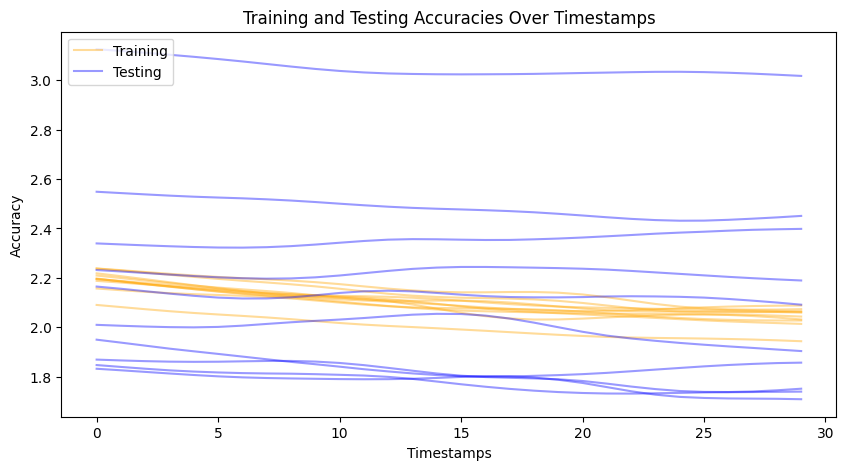

In [ ]:
from matplotlib import pyplot as plt
def show_train_and_test_accuracy_over_epochs(history):
	# Initialize lists to store accuracies for each fold
	train_fold_accuracies = np.zeros((len(history["train"][-1]), len(history["train"])))
	test_fold_accuracies = np.zeros((len(history["train"][-1]), len(history["train"])))

	# Extract training and testing accuracies for each fold across all epochs
	for epoch_index, epoch_data in enumerate(history["train"]):
		for fold_index, fold_data in enumerate(epoch_data):
			train_fold_accuracies[fold_index][epoch_index] = fold_data

	for epoch_index, epoch_data in enumerate(history["test"]):
		for fold_index, fold_data in enumerate(epoch_data):
			test_fold_accuracies[fold_index][epoch_index] = fold_data

	# Plot training and testing accuracies for each fold on one graph
	plt.figure(figsize=(10, 5))
	for fold_index, accuracies in enumerate(train_fold_accuracies):
		plt.plot(accuracies, color='orange', alpha=.4)
	for fold_index, accuracies in enumerate(test_fold_accuracies):
		plt.plot(accuracies, color='blue', alpha=.4)

	# Add custom legend
	leg = plt.legend(['Training', 'Testing'], loc='upper left')
	leg.legend_handles[0].set_color('orange')
	leg.legend_handles[1].set_color('blue')

	plt.xlabel('Timestamps')
	plt.ylabel('Accuracy')
	#plt.xticks(np.arange(1, len(history["train"]), step=1))
	plt.title('Training and Testing Accuracies Over Timestamps')
	plt.show()

show_train_and_test_accuracy_over_epochs(history)